# Explanation

This notebook is gonna be a first of a series of notebooks for the Value Investing Machine Learning project to establish a baseline as a iteration zero for future reference.

Further explanation of the value investing project can be found in the docs -> Domain analysis document

# Initial Setup

Below is the install command for the needed libraries to run the notebook

pip install scipy scikit-learn pandas seaborn shap


In [8]:
import io, math
from scipy.io import arff
from sklearn.metrics import max_error
from sklearn.metrics import mean_squared_error

import sklearn
import pandas as pd
import seaborn
import shap

# Data provisioning

The dataset consist of 28 columns. Ranging from 7 million to 22 million rows per column, with a total file size of 3.6gb. This immediately shows a processing problem where trying to do anything with the dataset requires alot of compute.

We can try and tackle this. By limiting the columns we actually need from the dataset. For now we gonna just take the colums that have been mentioned in the expert interview or are most closely related.

Also for these columns we dont need to load in all rows. Since the dataset contains a span of 20 years. So ideally we only want to take more recent data. For example the past 3 years.

While doing this we are gonna try and create a new filtered dataset. Consisting of fewer column and only past data rows of 3 years. That filtered dataset we will use further for our model.

# Data Dictionary
Identifiers  
Ticker: Company trading symbol  
Date: Date of the observation (price + ratios)  

Price / Market  
Adjusted Close (Target Variable): Realistic price including dividends and splits. Used for return calculations.  
Volume: Indicates market activity and sentiment around a stock.  
Market Cap: Company size. Smaller companies may have more pricing inefficiencies.  

Valuation (Core for value investing)  
P/E (ttm): Price relative to earnings. Used to assess how expensive a company is.  
P/S (ttm): Price relative to revenue. Useful when earnings are less reliable.  
P/B: Price relative to assets. Classic value investing metric.  
P/FCF (ttm): Price relative to free cash flow.  
EV/EBITDA: Measures value based on operational cash flow. Widely used by professionals.  
EV/Sales: Alternative valuation when profits are unstable.  

Value Signal  
Book to Market Value: Inverse of P/B. Indicates how “cheap” a stock is relative to its assets.  

Quality (avoid value traps).  
Operating Income/EV: Measures profitability relative to company value.  
Altman Z Score: Financial health indicator. Helps detect risk of bankruptcy.  


Optional  
Dividend Yield: Income return from dividends.  
Stakeholder mentioned dividend as an important anchor in valuation shows reliability of company.  

Data Choice  
The dataset contains both quarterly and yearly (TTM) data we will use past data of 3 years.  
For this model, TTM data is used because:

It reduces short-term noise  
It better reflects long-term earning capacity  
It aligns with how the stakeholder evaluates companies with long term vision in mind.  

In [9]:
#data column selection only exectued once to select columns
if False:
    df = pd.read_csv("../Dataset/us-derived-shareprices-daily.csv", sep=";")
    df.columns = df.columns.str.strip()

    print(df.columns.tolist())

Make sure we select the right columns from the initial dataset.

In [10]:
# Data filtering step (executed once to create smaller working dataset)
if False:

    # columns we want to use
    cols = [
        "Ticker", 
        "Date", 
        "Adj. Close", 
        "Volume", 
        "Market-Cap",
        "Price to Earnings Ratio (ttm)",
        "Price to Sales Ratio (ttm)",
        "Price to Book Value",
        "Price to Free Cash Flow (ttm)",
        "EV/EBITDA", 
        "EV/Sales",
        "Book to Market Value",
        "Operating Income/EV",
        "Altman Z Score",
        "Dividend Yield"
    ]

    # load only selected columns
    df = pd.read_csv(
        "us-derived-shareprices-daily/us-derived-shareprices-daily.csv",
        usecols=cols,
        sep=";"
    )

    # convert Date column
    df["Date"] = pd.to_datetime(df["Date"])

    # filter between 2022 and end of 2025
    df = df[df["Date"].between("2022-01-01", "2025-12-31")]

    # save filtered dataset
    df.to_csv("filtered_shares_ratios_3years.csv", index=False)

    print("created filtered dataset")


df = pd.read_csv("../filtered_shares_ratios_3years.csv")
df.describe()


,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,5.077223e+06,5.077223e+06,4.846845e+06,3.619868e+06,3.274182e+06,4.048688e+06,2.758179e+06,3.212294e+06,3.200910e+06,3.972041e+06,3.577781e+06,2.859125e+06,1.636477e+06
mean,2.508054e+04,1.703947e+06,4.219712e+12,-1.730331e+01,1.370486e+02,1.063825e+01,-2.022930e+01,1.040932e+00,7.648980e+01,1.096683e+01,-8.269594e+00,2.341573e+01,2.185915e+00
std,1.419652e+06,1.106200e+07,4.197879e+14,2.812195e+03,3.520416e+03,1.900016e+03,2.239674e+03,1.370573e+03,3.095022e+03,8.267660e+02,9.473802e+02,2.024572e+03,2.855518e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-1.000000e+05,-3.576344e+04
25%,5.780000e+00,3.290600e+04,1.301741e+08,-3.799602e+00,7.373900e-01,7.864400e-01,-2.938540e+00,-7.300700e-01,8.751400e-01,1.875300e-01,-5.040000e-02,6.364500e-01,1.068000e-02
50%,1.626000e+01,2.620240e+05,7.850186e+08,6.453625e+00,1.953155e+00,1.616180e+00,5.291540e+00,7.518780e+00,2.221115e+00,4.889800e-01,3.346000e-02,2.211520e+00,2.341000e-02
75%,4.615000e+01,1.039564e+06,4.506176e+09,2.126395e+01,4.593700e+00,3.642730e+00,1.524451e+01,1.497710e+01,5.223825e+00,9.737800e-01,8.125000e-02,4.288110e+00,4.275000e-02
max,1.000000e+08,5.497020e+09,5.698460e+16,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,2.414675e+04


Created a filtered dataset reduced from 28 to 15 columns.

Since the datasets are to big to push to github and don't belong in github. Added datasets .csv, .parquet, .xslx files to gitignore.

In [11]:
pd.options.display.float_format = '{:,.0f}'.format
df.describe()

,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
count,"5,077,223","5,077,223","4,846,845","3,619,868","3,274,182","4,048,688","2,758,179","3,212,294","3,200,910","3,972,041","3,577,781","2,859,125","1,636,477"
mean,"25,081","1,703,947","4,219,712,248,792",-17,137,11,-20,1,76,11,-8,23,2
std,"1,419,652","11,062,003","419,787,899,198,825","2,812","3,520","1,900","2,240","1,371","3,095",827,947,"2,025",286
min,0,0,0,"-100,000","-100,000","-100,000","-100,000","-100,000","-100,000","-100,000","-100,000","-100,000","-35,763"
25%,6,"32,906","130,174,107",-4,1,1,-3,-1,1,0,-0,1,0
50%,16,"262,024","785,018,580",6,2,2,5,8,2,0,0,2,0
75%,46,"1,039,564","4,506,176,000",21,5,4,15,15,5,1,0,4,0
max,"100,000,000","5,497,020,301","56,984,601,529,800,000","100,000","100,000","100,000","100,000","100,000","100,000","100,000","100,000","100,000","24,147"


In [12]:
df.sample(5)

,Ticker,Date,Adj. Close,Volume,Market-Cap,Price to Earnings Ratio (ttm),Price to Sales Ratio (ttm),Price to Book Value,Price to Free Cash Flow (ttm),EV/EBITDA,EV/Sales,Book to Market Value,Operating Income/EV,Altman Z Score,Dividend Yield
912371,CFB,2023-01-05,12,117236,"593,136,916",9,3,1,NaN,NaN,NaN,1,NaN,NaN,NaN
2006248,GOVX,2025-01-06,65,27442,"24,533,779",NaN,NaN,1,NaN,NaN,NaN,1,NaN,NaN,NaN
3280826,NWG,2022-04-11,4,1244079,"65,450,070,494",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2245697,HWNI,2023-10-10,20,377,"18,829,045",-0,0,2,NaN,-2,1,1,-1,-4,NaN
4994091,XNCR,2022-09-26,25,253535,"1,434,793,109",64,5,2,NaN,16,3,1,0,9,NaN


Heere is a random sample taken from the data. We can see alot of missing or unusable values as well as very fluctuating values. Since this is the baseline model we won't dive into fixing this.

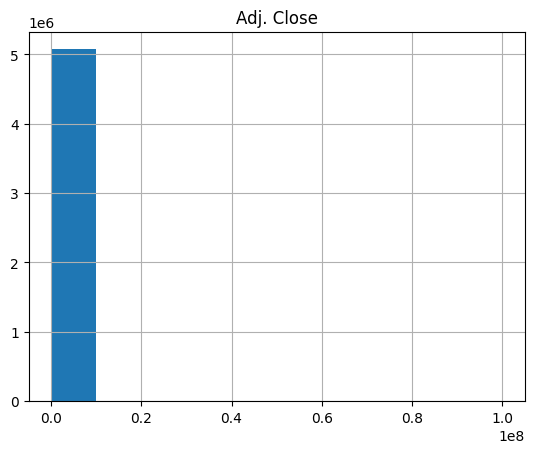

In [13]:
plot = df.hist(column="Adj. Close")